# BFGS vs Gradient Descent

BFGS builds curvature information through rank-two Hessian-inverse updates:
$$
H_{k+1}=(I-\rho s y^\top)H_k(I-\rho y s^\top)+\rho ss^\top,\quad \rho=\frac1{y^\top s}.
$$
This often accelerates convergence on ill-conditioned smooth objectives.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/bfgs-lbfgs") if Path("python/bfgs-lbfgs").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


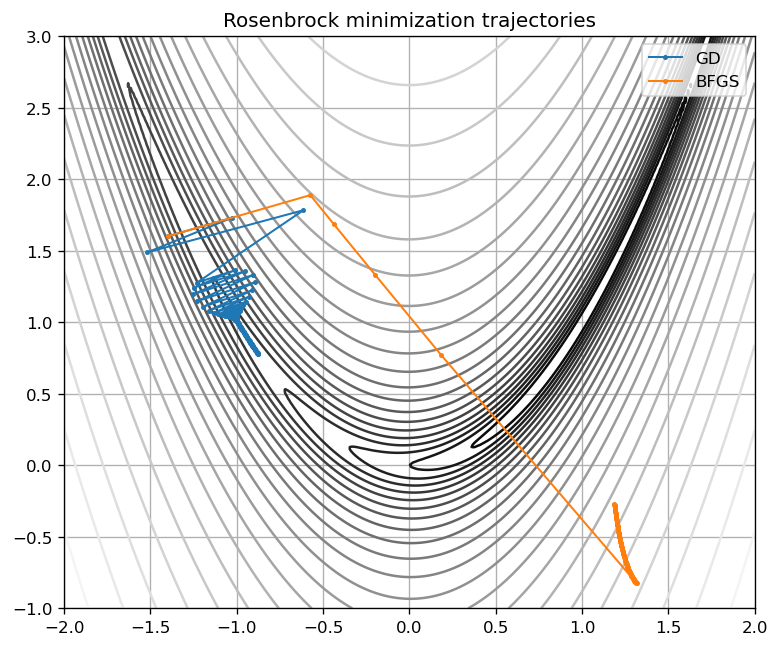

In [2]:
def f(x):
    x1, x2 = x
    return 100*(x2-x1**2)**2 + (1-x1)**2
def grad(x):
    x1, x2 = x
    return np.array([-400*x1*(x2-x1**2)-2*(1-x1), 200*(x2-x1**2)])

x0 = np.array([-1.4, 1.6], dtype=float)
n_it = 120

# Gradient descent
xg = x0.copy()
traj_g=[xg.copy()]
for _ in range(n_it):
    g = grad(xg)
    alpha = 0.0018
    xg = xg - alpha*g
    traj_g.append(xg.copy())

# BFGS
xb = x0.copy()
H = np.eye(2)
traj_b=[xb.copy()]
for _ in range(n_it):
    g = grad(xb)
    p = -H @ g
    alpha = 0.004
    xn = xb + alpha*p
    s = xn - xb
    y = grad(xn) - g
    ys = y @ s
    if ys > 1e-12:
        rho = 1.0/ys
        I = np.eye(2)
        H = (I-rho*np.outer(s,y)) @ H @ (I-rho*np.outer(y,s)) + rho*np.outer(s,s)
    xb = xn
    traj_b.append(xb.copy())

traj_g = np.array(traj_g); traj_b = np.array(traj_b)

X1 = np.linspace(-2, 2, 260)
X2 = np.linspace(-1, 3, 260)
XX1, XX2 = np.meshgrid(X1, X2)
ZZ = 100*(XX2-XX1**2)**2 + (1-XX1)**2

fig, ax = plt.subplots(figsize=(6.6,5.5))
ax.contour(XX1, XX2, np.log10(ZZ+1), levels=28, cmap="gray")
ax.plot(traj_g[:,0], traj_g[:,1], "-o", ms=2, lw=1.2, label="GD")
ax.plot(traj_b[:,0], traj_b[:,1], "-o", ms=2, lw=1.2, label="BFGS")
ax.set_title("Rosenbrock minimization trajectories")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Nocedal and S. Wright, *Numerical Optimization*.
- L. N. Trefethen, *Finite Difference and Spectral Methods* (lecture notes).
- D. P. Bertsekas, *Nonlinear Programming*.
